In [91]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns   
from sklearn.discriminant_analysis import StandardScaler
import numpy as np
from sklearn.neighbors import NearestNeighbors
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier


In [92]:
# Define home directory
home_dir = '/zhome/d0/a/221493/thesis/'
data_dir = home_dir + 'data/'

In [93]:
DISEASE = 'effusion'

## Assess the Baseline C0 Model
> densenet121-res224-chex

### Train and Validation sets 
- Included path, probability by C0, true label, correctness score (1 if C0 was right), and margin

In [94]:
# Load baseline predicitons by C0 for Pleural Effusion

train_c0 = pd.read_csv(home_dir + f'results/C0_baseline/{DISEASE}/train_c0_{DISEASE}.csv')
train_c0.head()

,path,prob,true,pred,correct,margin
0,CheXpert-v1.0-small/train/patient00001/study1/...,0.641115,0.0,0,1,0.002689
1,CheXpert-v1.0-small/train/patient00002/study2/...,0.681220,1.0,1,1,0.037416
2,CheXpert-v1.0-small/train/patient00004/study1/...,0.570345,0.0,0,1,0.073459
3,CheXpert-v1.0-small/train/patient00005/study1/...,0.579604,0.0,0,1,0.064200
4,CheXpert-v1.0-small/train/patient00006/study1/...,0.556092,0.0,0,1,0.087712


In [95]:

valid_c0 = pd.read_csv(home_dir + f'results/C0_baseline/{DISEASE}/valid_c0_{DISEASE}.csv')
valid_c0.head()

,path,prob,true,pred,correct,margin
0,CheXpert-v1.0-small/valid/patient64541/study1/...,0.615238,1.0,0,0,0.028566
1,CheXpert-v1.0-small/valid/patient64542/study1/...,0.509363,0.0,0,1,0.134441
2,CheXpert-v1.0-small/valid/patient64543/study1/...,0.657029,1.0,1,1,0.013225
3,CheXpert-v1.0-small/valid/patient64544/study1/...,0.506830,0.0,0,1,0.136974
4,CheXpert-v1.0-small/valid/patient64545/study1/...,0.681022,1.0,1,1,0.037218


Class distribution in training set:
true
1.0    30873
0.0    15675
Name: count, dtype: int64

Class distribution in validation set:
true
1.0    116
0.0     84
Name: count, dtype: int64



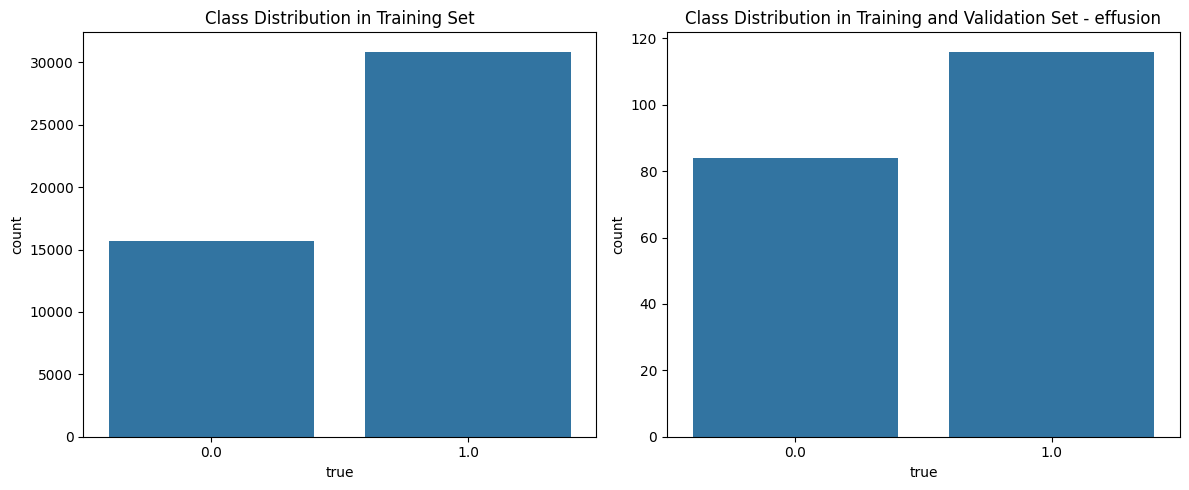

In [96]:
# Plot frequency of classes in train and validation set
print(f'Class distribution in training set:\n{train_c0["true"].value_counts()}\n')
print(f'Class distribution in validation set:\n{valid_c0["true"].value_counts()}\n')
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.countplot(x='true', data=train_c0)
plt.title('Class Distribution in Training Set')
plt.subplot(1, 2, 2)
sns.countplot(x='true', data=valid_c0)
plt.title(f'Class Distribution in Validation Set')
plt.tight_layout()
plt.title(f'Class Distribution in Training and Validation Set - {DISEASE}')
plt.show()

### Summary of C0's performance on Effusion

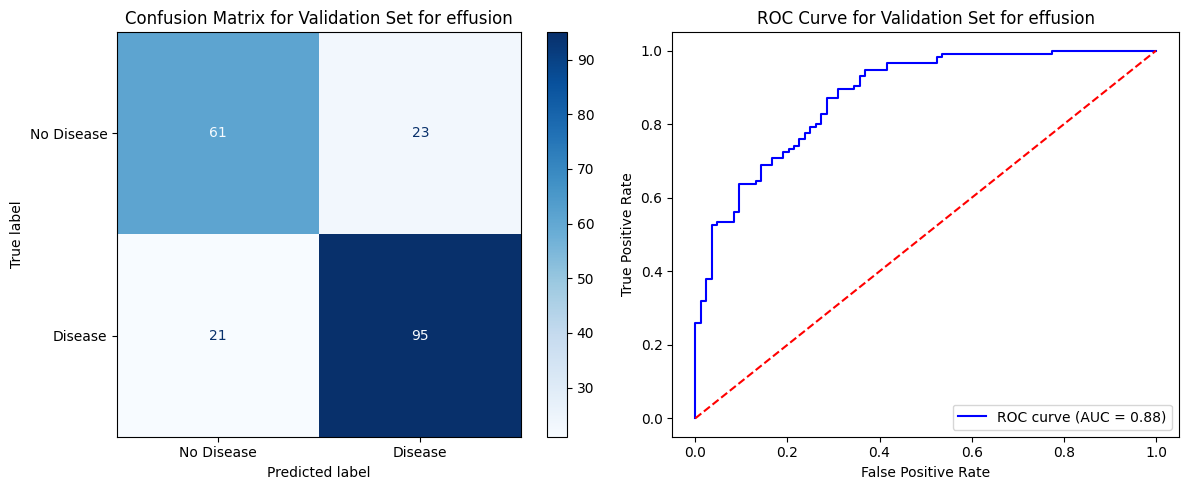

In [97]:
# Confusion matrix for validation set and ROC curve side by side
# Start with confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc    
y_true = valid_c0['true']
y_pred = valid_c0['pred']
y_prob = valid_c0['prob']
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Disease', 'Disease'])
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
disp.plot(cmap='Blues', ax=plt.gca())
plt.title(f'Confusion Matrix for Validation Set for {DISEASE}')
# Now ROC curve
fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)
plt.subplot(1, 2, 2)
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve for Validation Set for {DISEASE}')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

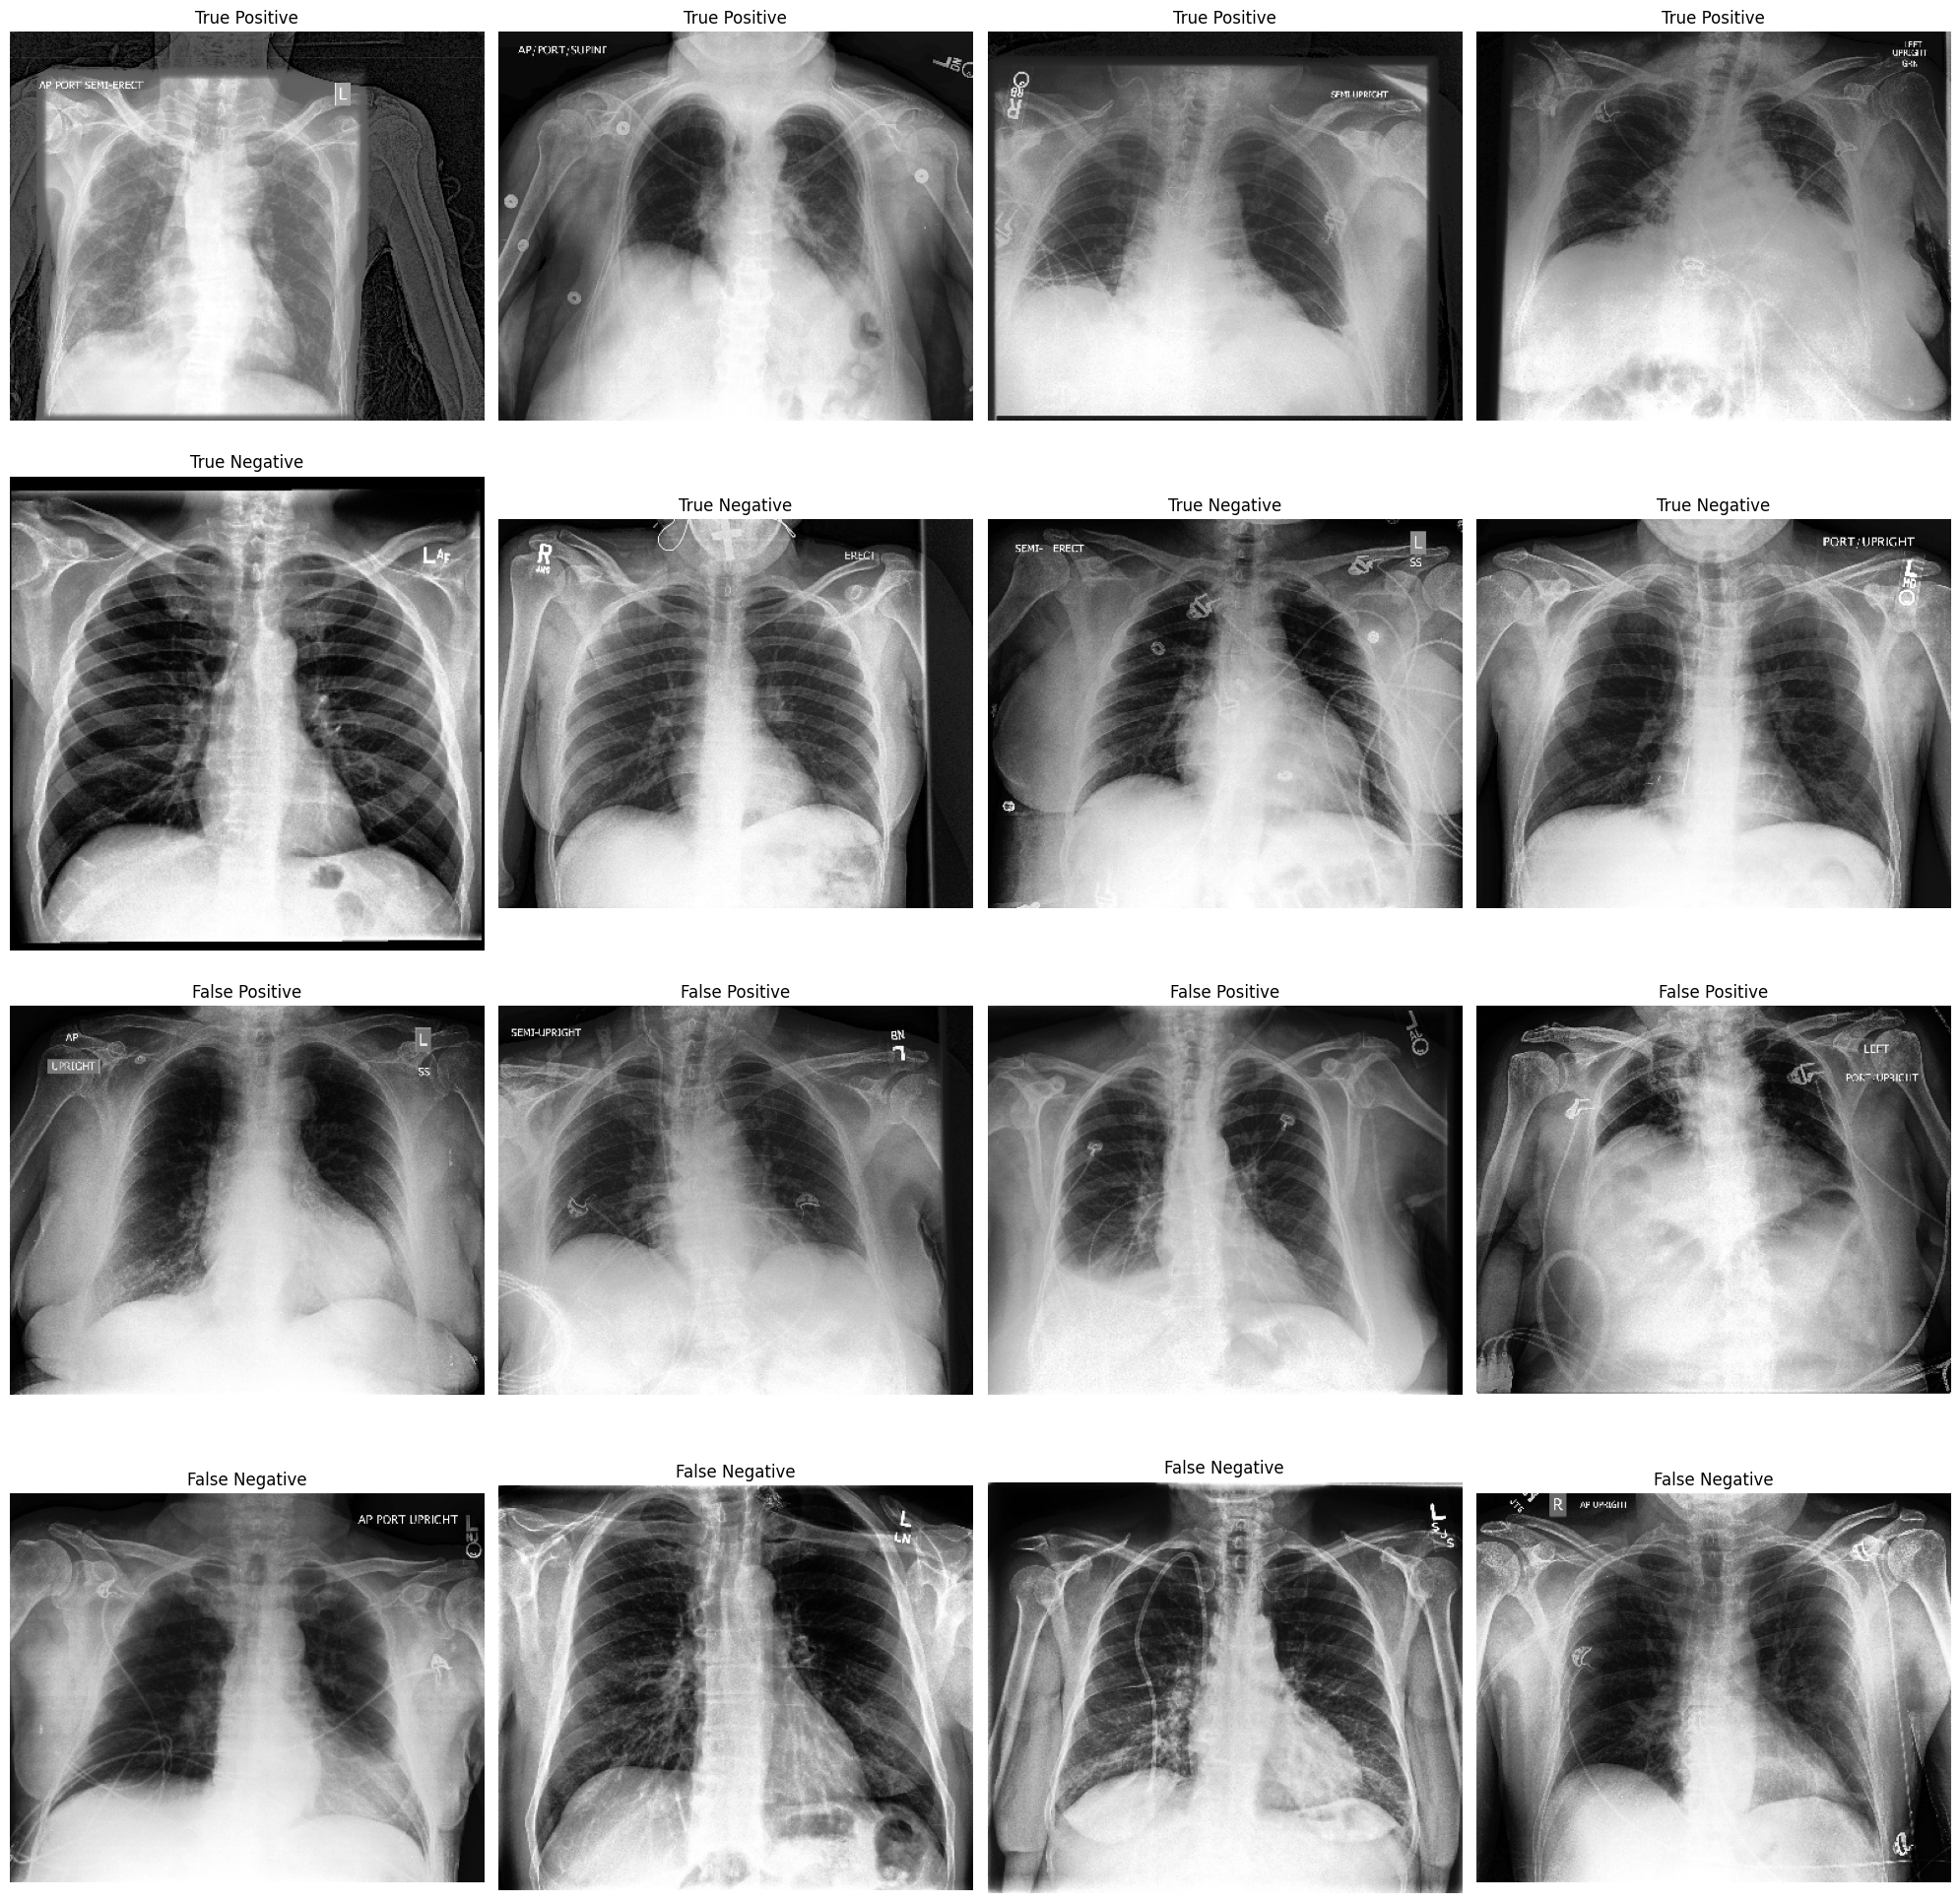

In [98]:
scenarios = {
    'True Positive':  [valid_c0[(valid_c0['true'] == 1) & (valid_c0['pred'] == 1)].iloc[i]['path'] for i in range(min(4, len(valid_c0[(valid_c0['true'] == 1) & (valid_c0['pred'] == 1)])))],
    'True Negative':  [valid_c0[(valid_c0['true'] == 0) & (valid_c0['pred'] == 0)].iloc[i]['path'] for i in range(min(4, len(valid_c0[(valid_c0['true'] == 0) & (valid_c0['pred'] == 0)])))],
    'False Positive': [valid_c0[(valid_c0['true'] == 0) & (valid_c0['pred'] == 1)].iloc[i]['path'] for i in range(min(4, len(valid_c0[(valid_c0['true'] == 0) & (valid_c0['pred'] == 1)])))],
    'False Negative': [valid_c0[(valid_c0['true'] == 1) & (valid_c0['pred'] == 0)].iloc[i]['path'] for i in range(min(4, len(valid_c0[(valid_c0['true'] == 1) & (valid_c0['pred'] == 0)])))],
}

plt.figure(figsize=(20, 20))
for row, (title, examples) in enumerate(scenarios.items()):
    for col in range(4):
        plt.subplot(4, 4, row * 4 + col + 1)
        if col < len(examples):
            plt.imshow(plt.imread(data_dir + examples[col]), cmap='gray')
            plt.title(title)
        else:
            plt.text(0.5, 0.5, 'No Examples', ha='center', va='center', transform=plt.gca().transAxes)
        plt.axis('off')
plt.tight_layout()
plt.show()


In [99]:
# Analyse the error made by the model, by looking at the false positives and false negatives.
# Print number of false positives and false negatives
num_true_positives = len(valid_c0[(valid_c0['true'] == 1) & (valid_c0['pred'] == 1)])
num_true_negatives = len(valid_c0[(valid_c0['true'] == 0) & (valid_c0['pred'] == 0)])
num_false_positives = len(valid_c0[(valid_c0['true'] == 0) & (valid_c0['pred'] == 1)])
num_false_negatives = len(valid_c0[(valid_c0['true'] == 1) & (valid_c0['pred'] == 0)])
print(f'Number of True Positives: {num_true_positives}')
print(f'Number of True Negatives: {num_true_negatives}')
print(f'Number of False Positives: {num_false_positives}')
print(f'Number of False Negatives: {num_false_negatives}')

Number of True Positives: 95
Number of True Negatives: 61
Number of False Positives: 23
Number of False Negatives: 21


## Baseline - Can we train C2 (a quality control model) using only the probs by C0? 
- Will it accurately determine correct and wrong predictions?

In [100]:
# C2 will use [PROB] as its only feature and [CORRECT] as its target, where [CORRECT] is 1 if the prediction is correct and 0 if it is incorrect. 
# Create a new dataframe for C2 with these columns.
c2_train_df = pd.DataFrame()
c2_train_df['PROB'] = train_c0['prob']
c2_train_df['CORRECT'] = (train_c0['true'] == train_c0['pred']).astype(int)

c2_valid_df = pd.DataFrame()
c2_valid_df['PROB'] = valid_c0['prob']
c2_valid_df['CORRECT'] = (valid_c0['true'] == valid_c0['pred']).astype(int)   

In [101]:
c2_train_df

,PROB,CORRECT
0,0.641115,1
1,0.681220,1
2,0.570345,1
3,0.579604,1
4,0.556092,1
...,...,...
46543,0.527807,1
46544,0.537119,0
46545,0.673462,1
46546,0.676210,1


In [102]:
c2_valid_df

,PROB,CORRECT
0,0.615238,0
1,0.509363,1
2,0.657029,1
3,0.506830,1
4,0.681022,1
...,...,...
195,0.682796,0
196,0.625245,1
197,0.579751,0
198,0.533991,1


In [103]:
# Train a simple logistic regression model for C2 using PROB as the only feature and CORRECT as the target. Evaluate the model on the validation set and print the accuracy, precision, recall, and F1 score.
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
X_train = c2_train_df[['PROB']]
y_train = c2_train_df['CORRECT']
X_valid = c2_valid_df[['PROB']]
y_valid = c2_valid_df['CORRECT']
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [104]:
y_pred = model.predict(X_valid)
accuracy = accuracy_score(y_valid, y_pred)
precision = precision_score(y_valid, y_pred)
recall = recall_score(y_valid, y_pred)
f1 = f1_score(y_valid, y_pred)
print(f'Accuracy: {accuracy:.2f}')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1 Score: {f1:.2f}')

Accuracy: 0.78
Precision: 0.78
Recall: 1.00
F1 Score: 0.88


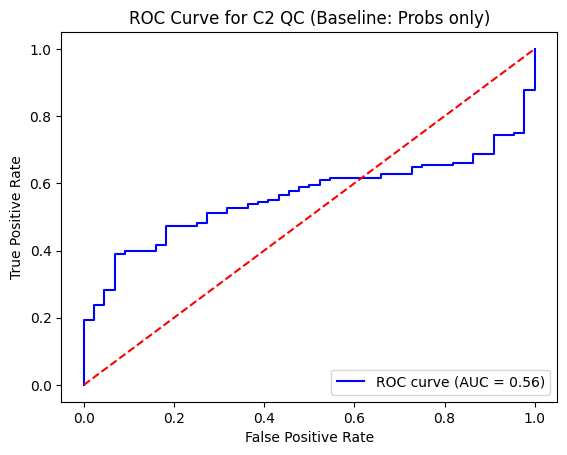

In [105]:
# ROC curve for C2
y_prob = model.predict_proba(X_valid)[:, 1]
fpr, tpr, _ = roc_curve(y_valid, y_prob)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for C2 QC (Baseline: Probs only)')
plt.legend(loc='lower right')
plt.show()

# 1st Simplified Attempt - Is there information in the counterfactual changes?
- We fake counterfactual samples
     - We take our sample, and our counterfactual is the other closest sample that has a flipped prediction
- And determine the difference in atributes between the counterfactual and the original image (delta-A)
- Then train C2 using [delta-A] as Feature and [CORRECT] as target

In [106]:
# Load the C1 (attribute vectors) for training and validation set

c1_train_df = pd.read_csv(home_dir + f'results/C1_attributes/train_c1_attribute_vector.csv')
c1_valid_df = pd.read_csv(home_dir + f'results/C1_attributes/valid_c1_attribute_vector.csv')


In [107]:
# Merge the baseline predictions with the attribute vectors by path
train_c2 = train_c0.merge(c1_train_df, on='path', how='left')
valid_c2 = valid_c0.merge(c1_valid_df, on='path', how='left')
train_c2

,path,prob,true,pred,correct,margin,patient_id,age_pred,sex_male,sex_female,...,Right Hilus Pulmonis_area_pixels,Right Hilus Pulmonis_bbox_width,Right Hilus Pulmonis_bbox_height,Right Hilus Pulmonis_bbox_ratio,Right Hilus Pulmonis_perimeter,Aorta_area_pixels,Aorta_bbox_width,Aorta_bbox_height,Aorta_bbox_ratio,Aorta_perimeter
0,CheXpert-v1.0-small/train/patient00001/study1/...,0.641115,0.0,0,1,0.002689,patient00001,46.296631,7.792770e-07,9.999992e-01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,CheXpert-v1.0-small/train/patient00002/study2/...,0.681220,1.0,1,1,0.037416,patient00002,63.702305,1.760454e-05,9.999824e-01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,CheXpert-v1.0-small/train/patient00004/study1/...,0.570345,0.0,0,1,0.073459,patient00004,26.006752,3.213766e-03,9.967862e-01,...,3625.0,51.0,129.0,0.395349,310.208150,2958.0,38.0,97.0,3.917526e-01,235.681239
3,CheXpert-v1.0-small/train/patient00005/study1/...,0.579604,0.0,0,1,0.064200,patient00005,41.602314,9.999933e-01,6.703691e-06,...,2209.0,38.0,92.0,0.413043,223.681239,1585.0,40.0,57.0,7.017544e-01,159.438598
4,CheXpert-v1.0-small/train/patient00006/study1/...,0.556092,0.0,0,1,0.087712,patient00006,51.069099,3.701182e-01,6.298818e-01,...,6660.0,74.0,146.0,0.506849,399.462984,5355.0,71.0,96.0,7.395833e-01,286.208151
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46543,CheXpert-v1.0-small/train/patient64532/study1/...,0.527807,0.0,0,1,0.115997,patient64532,50.757626,2.449746e-03,9.975503e-01,...,2256.0,49.0,66.0,0.742424,184.308656,3.0,2.0,0.0,2.000000e+06,4.000000
46544,CheXpert-v1.0-small/train/patient64534/study1/...,0.537119,1.0,0,0,0.106685,patient64534,64.415741,9.991718e-01,8.281596e-04,...,4682.0,69.0,132.0,0.522727,331.705624,3904.0,67.0,83.0,8.072289e-01,251.279218
46545,CheXpert-v1.0-small/train/patient64535/study1/...,0.673462,1.0,1,1,0.029658,patient64535,60.565922,1.000000e+00,8.610759e-09,...,6651.0,109.0,191.0,0.570681,551.487369,5883.0,57.0,142.0,4.014084e-01,390.391916
46546,CheXpert-v1.0-small/train/patient64539/study1/...,0.676210,1.0,1,1,0.032406,patient64539,13.358482,7.092757e-01,2.907243e-01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [108]:
def add_clinical_ratios(df):
    df = df.copy()
    
    # Cardiothoracic ratio — most important for cardiomegaly
    # Normal < 0.5, enlarged heart > 0.5
    df['cardiothoracic_ratio'] = df['Heart_bbox_width'] / (df['Left Lung_bbox_width'] + df['Right Lung_bbox_width'])
    
    # Lung symmetry — asymmetry can indicate effusion or pneumothorax
    df['lung_area_ratio']      = df['Left Lung_area_pixels'] / (df['Right Lung_area_pixels'] + 1e-6)
    df['lung_height_ratio']    = df['Left Lung_bbox_height'] / (df['Right Lung_bbox_height'] + 1e-6)
    df['lung_width_ratio']     = df['Left Lung_bbox_width']  / (df['Right Lung_bbox_width']  + 1e-6)
    
    # Lung area relative to total image area — captures hyperinflation/collapse
    total_area = df['Left Lung_area_pixels'] + df['Right Lung_area_pixels']
    df['left_lung_fraction']   = df['Left Lung_area_pixels']  / (total_area + 1e-6)
    df['right_lung_fraction']  = df['Right Lung_area_pixels'] / (total_area + 1e-6)
    
    # Mediastinal width relative to lung width — widens in effusion/cardiomegaly
    df['mediastinal_ratio']    = df['Mediastinum_bbox_width'] / (df['Left Lung_bbox_width'] + df['Right Lung_bbox_width'] + 1e-6)

    return df

In [109]:
### COMMENTED OUT

'''
DISEASE_PREFIXES = {
    'effusion':     ["Left Lung", "Right Lung", "Facies Diaphragmatica",
                     "Left Hilus Pulmonis", "Right Hilus Pulmonis", "Mediastinum"],
    'pneumothorax': ["Left Lung", "Right Lung", "Mediastinum"],
    'cardiomegaly': ["Heart", "Aorta", "Mediastinum"],
    'atelectasis':  ["Left Lung", "Right Lung", "Facies Diaphragmatica",
                     "Left Hilus Pulmonis", "Right Hilus Pulmonis", "Mediastinum", "Heart"],
}

DISEASE_RATIO_COLS = {
    'effusion':     ['lung_area_ratio', 'lung_height_ratio', 'lung_width_ratio',
                     'left_lung_fraction', 'right_lung_fraction', 'mediastinal_ratio'],
    'pneumothorax': ['lung_area_ratio', 'lung_height_ratio', 'lung_width_ratio',
                     'left_lung_fraction', 'right_lung_fraction', 'mediastinal_ratio'],
    'cardiomegaly': ['cardiothoracic_ratio', 'mediastinal_ratio'],
    'atelectasis':  ['lung_area_ratio', 'lung_height_ratio', 'lung_width_ratio',
                     'left_lung_fraction', 'right_lung_fraction', 'mediastinal_ratio'],
}


pixel_cols = [
    col for col in train_c2.columns
    if any(col.lower().startswith(p.lower()) for p in DISEASE_PREFIXES[DISEASE])]

'''

'\nDISEASE_PREFIXES = {\n    \'effusion\':     ["Left Lung", "Right Lung", "Facies Diaphragmatica",\n                     "Left Hilus Pulmonis", "Right Hilus Pulmonis", "Mediastinum"],\n    \'pneumothorax\': ["Left Lung", "Right Lung", "Mediastinum"],\n    \'cardiomegaly\': ["Heart", "Aorta", "Mediastinum"],\n    \'atelectasis\':  ["Left Lung", "Right Lung", "Facies Diaphragmatica",\n                     "Left Hilus Pulmonis", "Right Hilus Pulmonis", "Mediastinum", "Heart"],\n}\n\nDISEASE_RATIO_COLS = {\n    \'effusion\':     [\'lung_area_ratio\', \'lung_height_ratio\', \'lung_width_ratio\',\n                     \'left_lung_fraction\', \'right_lung_fraction\', \'mediastinal_ratio\'],\n    \'pneumothorax\': [\'lung_area_ratio\', \'lung_height_ratio\', \'lung_width_ratio\',\n                     \'left_lung_fraction\', \'right_lung_fraction\', \'mediastinal_ratio\'],\n    \'cardiomegaly\': [\'cardiothoracic_ratio\', \'mediastinal_ratio\'],\n    \'atelectasis\':  [\'lung_area_ratio\', \'

In [110]:
# Add clinical ratios first
train_c2 = add_clinical_ratios(train_c2)
valid_c2 = add_clinical_ratios(valid_c2)

# All attribute columns = everything after the 6 meta cols (path, prob, true, pred, correct, patient_id)
meta_cols = ["path", "prob", "true", "pred", "correct", "patient_id"]
relevant_columns = [c for c in train_c2.columns if c not in meta_cols]

cols_to_keep = meta_cols + relevant_columns

train_filtered = train_c2[cols_to_keep].dropna(subset=relevant_columns).copy()
valid_filtered = valid_c2[cols_to_keep].dropna(subset=relevant_columns).copy()

attr_scaler = StandardScaler()
train_filtered[relevant_columns] = attr_scaler.fit_transform(train_filtered[relevant_columns].values.astype(float))
valid_filtered[relevant_columns] = attr_scaler.transform(valid_filtered[relevant_columns].values.astype(float))

print(f"Disease        : {DISEASE}")
print(f"Total features : {len(relevant_columns)}")
print(f"Shape — train  : {train_filtered.shape}  valid: {valid_filtered.shape}")

Disease        : effusion
Total features : 84
Shape — train  : (35637, 90)  valid: (146, 90)


In [111]:
train_filtered

,path,prob,true,pred,correct,patient_id,margin,age_pred,sex_male,sex_female,...,Aorta_bbox_height,Aorta_bbox_ratio,Aorta_perimeter,cardiothoracic_ratio,lung_area_ratio,lung_height_ratio,lung_width_ratio,left_lung_fraction,right_lung_fraction,mediastinal_ratio
2,CheXpert-v1.0-small/train/patient00004/study1/...,0.570345,0.0,0,1,patient00004,0.138627,-2.273229,-1.111550,1.111550,...,0.920389,-0.009747,0.281473,-0.868165,-0.419233,-0.018836,-0.159317,-0.361347,0.361347,-1.034482
3,CheXpert-v1.0-small/train/patient00005/study1/...,0.579604,0.0,0,1,patient00005,-0.104076,-1.157315,0.921745,-0.921745,...,-0.883134,-0.009739,-0.920305,-0.944317,-0.866665,-1.035216,0.129158,-0.849207,0.849207,-0.196179
4,CheXpert-v1.0-small/train/patient00006/study1/...,0.556092,0.0,0,1,patient00006,0.512221,-0.479935,-0.363115,0.363114,...,0.875301,-0.009738,1.077905,-0.276399,0.851360,-0.080486,-0.099414,0.868649,-0.868649,-0.775463
6,CheXpert-v1.0-small/train/patient00008/study1/...,0.721643,1.0,1,1,patient00008,0.253450,1.131524,0.899856,-0.899856,...,0.063716,-0.009733,0.762654,0.209164,0.728878,1.080718,-0.408348,0.759041,-0.759041,-0.040267
7,CheXpert-v1.0-small/train/patient00010/study1/...,0.504805,0.0,0,1,patient00010,1.856520,-0.064503,-1.118103,1.118103,...,0.289156,-0.009742,0.063037,-0.988112,-0.006945,0.512025,-0.028470,0.061462,-0.061462,-0.898162
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46541,CheXpert-v1.0-small/train/patient64529/study1/...,0.578658,1.0,0,0,patient64529,-0.079266,1.088966,0.921573,-0.921573,...,0.920389,-0.009737,1.191604,-0.075546,-0.300207,-0.079370,0.315311,-0.236756,0.236756,0.961816
46542,CheXpert-v1.0-small/train/patient64531/study1/...,0.709767,1.0,1,1,patient64531,-0.057840,-0.724217,-1.118105,1.118105,...,-0.747870,-0.009729,0.025447,0.877829,0.205269,0.843218,-0.529200,0.269827,-0.269827,0.254037
46543,CheXpert-v1.0-small/train/patient64532/study1/...,0.527807,0.0,0,1,patient64532,1.253604,-0.502222,-1.113108,1.113108,...,-3.453154,49.568042,-3.370412,-0.683607,-0.158277,1.436623,-1.175928,-0.090901,0.090901,-0.897670
46544,CheXpert-v1.0-small/train/patient64534/study1/...,0.537119,1.0,0,0,patient64534,1.009514,0.475061,0.920070,-0.920070,...,0.289156,-0.009736,0.527336,-0.317370,0.299941,0.626003,0.385169,0.360850,-0.360850,0.347263


## Assess the Baseline C0 Model
> densenet121-res224-chex

### Calculate the mean attribute vector for each class and select most representative attributes

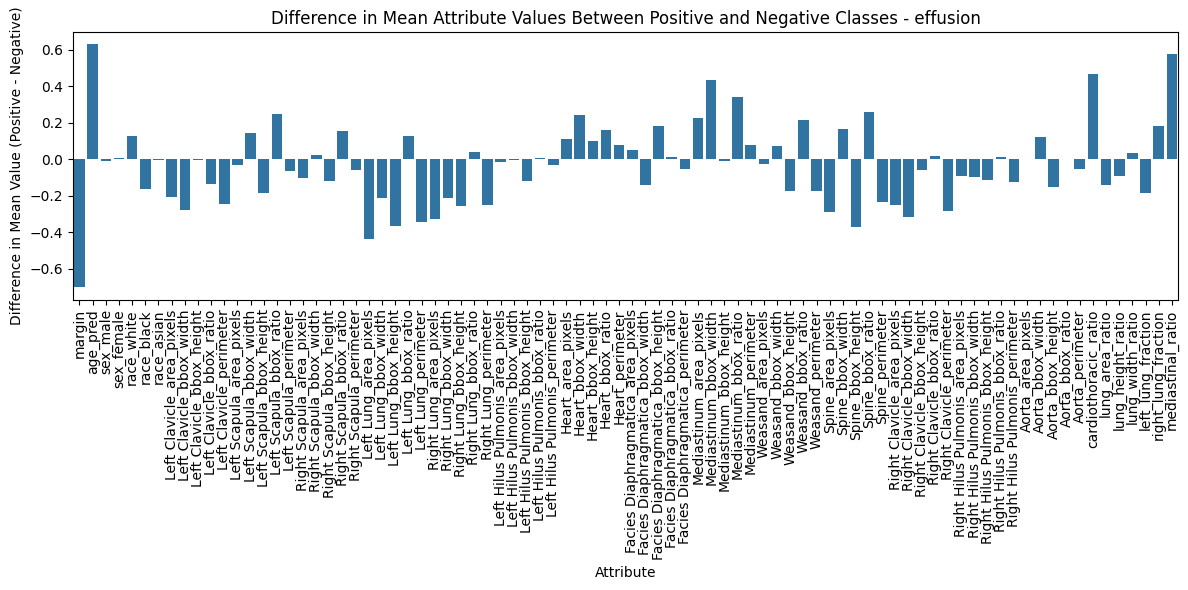

In [112]:
# Calculate the mean attribute vector for the positive and negative classes
disease_positive_mean = train_filtered[train_filtered['true'] == 1][relevant_columns].mean()
disease_negative_mean = train_filtered[train_filtered['true'] == 0][relevant_columns].mean()
difference = disease_positive_mean - disease_negative_mean

plt.figure(figsize=(12, 6))
sns.barplot(x=difference.index, y=difference.values)
plt.xticks(rotation=90)
plt.title(f'Difference in Mean Attribute Values Between Positive and Negative Classes - {DISEASE}')
plt.xlabel('Attribute')
plt.ylabel('Difference in Mean Value (Positive - Negative)')
plt.tight_layout()
plt.show()



## Now create the fake counterfactual for each image
#### THEORY: What is a fake counterfactual?
- A real counterfactual for sample i would be: the minimally different IMAGE that flips C0's prediction. We can't generate that yet (requires diffusion).
- Instead, we SIMULATE it by asking:
    - "What is the nearest training sample that C0 predicted with the OPPOSITE label?"

- KEY CHOICE: We use C0's PREDICTION (pred), NOT the ground truth (true).
- Why? Because we are probing C0's behaviour, not the disease severity.
- A real counterfactual flips C0's decision — so our fake CF must too.


In [113]:
# Split train into FOUR pools based on C0's PREDICTION and CORRECTNESS
# This ensures we match counterfactuals with the same correctness status
train_pred1_correct   = train_filtered[(train_filtered['pred'] == 1) & (train_filtered['correct'] == 1)]
train_pred1_incorrect = train_filtered[(train_filtered['pred'] == 1) & (train_filtered['correct'] == 0)]
train_pred0_correct   = train_filtered[(train_filtered['pred'] == 0) & (train_filtered['correct'] == 1)]
train_pred0_incorrect = train_filtered[(train_filtered['pred'] == 0) & (train_filtered['correct'] == 0)]

print(f"Training pool — C0 predicted positive AND correct:   {len(train_pred1_correct):,}")
print(f"Training pool — C0 predicted positive AND incorrect: {len(train_pred1_incorrect):,}")
print(f"Training pool — C0 predicted negative AND correct:   {len(train_pred0_correct):,}")
print(f"Training pool — C0 predicted negative AND incorrect: {len(train_pred0_incorrect):,}")
print("\nCounterfactual matching logic:")
print("  correct sample   → nearest correct sample with opposite prediction")
print("  incorrect sample → nearest incorrect sample with opposite prediction")

Training pool — C0 predicted positive AND correct:   16,019
Training pool — C0 predicted positive AND incorrect: 2,842
Training pool — C0 predicted negative AND correct:   10,164
Training pool — C0 predicted negative AND incorrect: 6,612

Counterfactual matching logic:
  correct sample   → nearest correct sample with opposite prediction
  incorrect sample → nearest incorrect sample with opposite prediction


In [114]:
train_pred1_correct

,path,prob,true,pred,correct,patient_id,margin,age_pred,sex_male,sex_female,...,Aorta_bbox_height,Aorta_bbox_ratio,Aorta_perimeter,cardiothoracic_ratio,lung_area_ratio,lung_height_ratio,lung_width_ratio,left_lung_fraction,right_lung_fraction,mediastinal_ratio
6,CheXpert-v1.0-small/train/patient00008/study1/...,0.721643,1.0,1,1,patient00008,0.253450,1.131524,0.899856,-0.899856,...,0.063716,-0.009733,0.762654,0.209164,0.728878,1.080718,-0.408348,0.759041,-0.759041,-0.040267
18,CheXpert-v1.0-small/train/patient00022/study2/...,0.726155,1.0,1,1,patient00022,0.371702,-0.451341,-1.118105,1.118105,...,-1.063486,-0.009741,-1.150870,0.066942,-2.346734,-2.279884,-1.285388,-2.719703,2.719703,-0.171516
25,CheXpert-v1.0-small/train/patient00031/study1/...,0.656201,1.0,1,1,patient00031,-1.461874,1.124878,0.890900,-0.890900,...,0.379332,-0.009743,0.046155,0.137109,0.355286,0.358266,0.170065,0.413523,-0.413523,1.710675
29,CheXpert-v1.0-small/train/patient00036/study1/...,0.707651,1.0,1,1,patient00036,-0.113304,0.356536,0.921759,-0.921759,...,-1.018398,-0.009734,-0.795789,-0.229735,-2.292944,-2.450225,-0.400519,-2.643759,2.643759,-0.320579
30,CheXpert-v1.0-small/train/patient00038/study1/...,0.719067,1.0,1,1,patient00038,0.185930,0.226176,0.921594,-0.921594,...,0.469508,-0.009737,0.599620,0.378454,-1.364559,-0.721223,-1.008562,-1.431264,1.431264,-1.006573
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46529,CheXpert-v1.0-small/train/patient64513/study1/...,0.695259,1.0,1,1,patient64513,-0.438137,-1.711473,0.921732,-0.921732,...,-0.522429,-0.009735,-0.222929,1.088991,-0.233736,-0.264205,-0.053487,-0.168085,0.168085,2.152147
46539,CheXpert-v1.0-small/train/patient64525/study1/...,0.706213,1.0,1,1,patient64525,-0.151000,1.348714,0.919958,-0.919958,...,1.236006,-0.009745,0.889683,0.013540,0.654108,1.264800,-0.402857,0.691256,-0.691256,0.108479
46540,CheXpert-v1.0-small/train/patient64526/study1/...,0.708958,1.0,1,1,patient64526,-0.079044,-0.776070,0.921731,-0.921731,...,0.334244,-0.009742,0.186897,0.364011,1.139447,0.291886,0.976851,1.119674,-1.119674,0.043397
46542,CheXpert-v1.0-small/train/patient64531/study1/...,0.709767,1.0,1,1,patient64531,-0.057840,-0.724217,-1.118105,1.118105,...,-0.747870,-0.009729,0.025447,0.877829,0.205269,0.843218,-0.529200,0.269827,-0.269827,0.254037


In [115]:
# We want the MINIMAL change — just like real counterfactuals are constrained to be minimally different from the original. 
# The nearest neighbour in attribute space gives us the closest point on the opposite side of C0's decision boundary, which is our best proxy for "what would minimally flip this prediction".

# Fit FOUR NN indices — one per (prediction class × correctness) combination
nn_pred1_correct = NearestNeighbors(n_neighbors=1, metric='euclidean', n_jobs=-1)
nn_pred1_correct.fit(train_pred1_correct[relevant_columns].values)

nn_pred1_incorrect = NearestNeighbors(n_neighbors=1, metric='euclidean', n_jobs=-1)
nn_pred1_incorrect.fit(train_pred1_incorrect[relevant_columns].values)

nn_pred0_correct = NearestNeighbors(n_neighbors=1, metric='euclidean', n_jobs=-1)
nn_pred0_correct.fit(train_pred0_correct[relevant_columns].values)

nn_pred0_incorrect = NearestNeighbors(n_neighbors=1, metric='euclidean', n_jobs=-1)
nn_pred0_incorrect.fit(train_pred0_incorrect[relevant_columns].values)

print("NN indices built on scaled Lung attributes using Euclidean distance.")
print("Euclidean distance treats all attribute deviations equally — robust to outliers.")
print("Matching strategy: correct samples → correct CFs | incorrect samples → incorrect CFs")

NN indices built on scaled Lung attributes using Euclidean distance.
Euclidean distance treats all attribute deviations equally — robust to outliers.
Matching strategy: correct samples → correct CFs | incorrect samples → incorrect CFs


### Calculate the change profiles
- For each sample, we "generate its fake CF" by finding its closest opposite neighbour, and calculate their delta-A

In [116]:
def compute_diff_vectors(df, 
                         nn_pred1_correct, nn_pred1_incorrect, 
                         nn_pred0_correct, nn_pred0_incorrect,
                         train_pred1_correct, train_pred1_incorrect,
                         train_pred0_correct, train_pred0_incorrect,
                         relevant_columns):
    query         = df[relevant_columns].values
    query_preds   = df['pred'].values.astype(int)
    query_correct = df['correct'].values.astype(int)
    diff_vecs     = np.empty((len(df), len(relevant_columns)), dtype=np.float64)

    # pred=1, correct=1 → search in pred=0, correct=1
    mask = (query_preds == 1) & (query_correct == 1)
    if mask.any():
        _, idxs      = nn_pred0_correct.kneighbors(query[mask])
        neighbours   = train_pred0_correct[relevant_columns].values[idxs[:, 0]]
        diff_vecs[mask] = query[mask] - neighbours

    # pred=1, correct=0 → search in pred=0, correct=0
    mask = (query_preds == 1) & (query_correct == 0)
    if mask.any():
        _, idxs      = nn_pred0_incorrect.kneighbors(query[mask])
        neighbours   = train_pred0_incorrect[relevant_columns].values[idxs[:, 0]]
        diff_vecs[mask] = query[mask] - neighbours

    # pred=0, correct=1 → search in pred=1, correct=1
    mask = (query_preds == 0) & (query_correct == 1)
    if mask.any():
        _, idxs      = nn_pred1_correct.kneighbors(query[mask])
        neighbours   = train_pred1_correct[relevant_columns].values[idxs[:, 0]]
        diff_vecs[mask] = query[mask] - neighbours

    # pred=0, correct=0 → search in pred=1, correct=0
    mask = (query_preds == 0) & (query_correct == 0)
    if mask.any():
        _, idxs      = nn_pred1_incorrect.kneighbors(query[mask])
        neighbours   = train_pred1_incorrect[relevant_columns].values[idxs[:, 0]]
        diff_vecs[mask] = query[mask] - neighbours

    return diff_vecs

train_diff = compute_diff_vectors(train_filtered, 
                                   nn_pred1_correct, nn_pred1_incorrect,
                                   nn_pred0_correct, nn_pred0_incorrect,
                                   train_pred1_correct, train_pred1_incorrect,
                                   train_pred0_correct, train_pred0_incorrect,
                                   relevant_columns)
valid_diff = compute_diff_vectors(valid_filtered, 
                                   nn_pred1_correct, nn_pred1_incorrect,
                                   nn_pred0_correct, nn_pred0_incorrect,
                                   train_pred1_correct, train_pred1_incorrect,
                                   train_pred0_correct, train_pred0_incorrect,
                                   relevant_columns)

diff_col_names = [f"delta_{c}" for c in relevant_columns]
print(f"ΔA shape — train: {train_diff.shape}  valid: {valid_diff.shape}") # -> FOR EACH ROW, THERES A DIFFERENCE VECTOR, ON HOW MUCH EACH ATTRIBUTE CHANGED BETWEEN THE SAMPLE AND ITS FAKE COUNTERFACTUAL

ΔA shape — train: (35637, 84)  valid: (146, 84)


### Checking the hypothesis
- Is the Delta-A (Atribute Change Profile) betwene samples and CF, different for correct and incorrect predictions? 
- Should be larger in correct ones.

Mean ΔA magnitude (L2 norm of difference vector):
  Correct predictions   : 6.3618
  Incorrect predictions : 6.2582
  ΔAverage l2 norm of the vectors: +0.1036

If Correct > Incorrect → the signal is working as hypothesised.


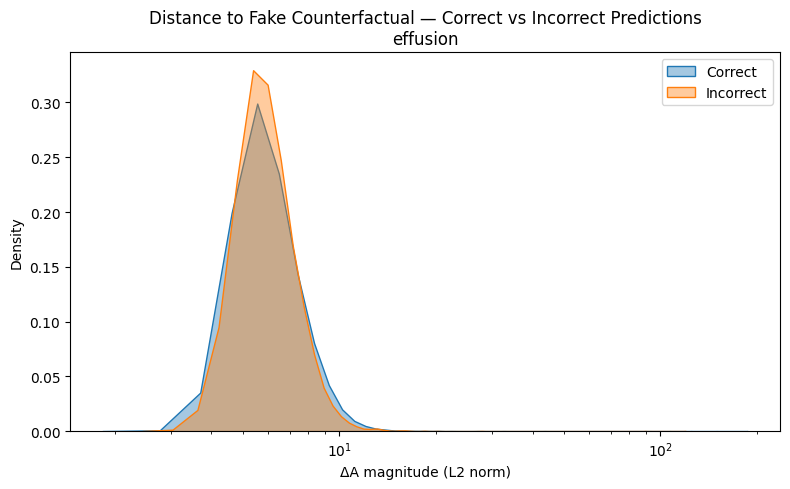

In [117]:
train_dist     = np.linalg.norm(train_diff, axis=1)
correct_mask   = train_filtered['correct'].values == 1

print("Mean ΔA magnitude (L2 norm of difference vector):")
print(f"  Correct predictions   : {train_dist[correct_mask].mean():.4f}")
print(f"  Incorrect predictions : {train_dist[~correct_mask].mean():.4f}")
print(f"  ΔAverage l2 norm of the vectors: {train_dist[correct_mask].mean() - train_dist[~correct_mask].mean():+.4f}")
print()
print("If Correct > Incorrect → the signal is working as hypothesised.")


# Visualise the ΔA magnitude distribution for correct vs incorrect predictions
plt.figure(figsize=(8, 5))
sns.kdeplot(train_dist[correct_mask],   label='Correct',   fill=True, alpha=0.4)
sns.kdeplot(train_dist[~correct_mask],  label='Incorrect', fill=True, alpha=0.4)
plt.xlabel('ΔA magnitude (L2 norm)')
plt.ylabel('Density')
plt.title(f'Distance to Fake Counterfactual — Correct vs Incorrect Predictions\n{DISEASE}')
plt.legend()
plt.xscale('log')
plt.tight_layout()
plt.show()

###  Training C2 on the ΔA
- Now we train C2 — the quality control classifier — using ΔA as its features and correct/incorrect as the target.
- Does ΔA add signal BEYOND what C0's confidence already tells us?

In [118]:
# Define the target
y_train = train_filtered['correct'].values
y_valid = valid_filtered['correct'].values

In [119]:
# Reusable train and test so we can use it for the baseline vs the new method

def train_and_eval(X_train, X_valid, y_train, y_valid, label):
    # Scale
    scaler   = StandardScaler()
    X_tr_sc  = scaler.fit_transform(X_train)
    X_va_sc  = scaler.transform(X_valid)
    
    # Train Model with balanced setting
    model    = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
    
    # Fit the model and predict
    model.fit(X_tr_sc, y_train)
    y_prob   = model.predict_proba(X_va_sc)[:, 1]
    y_pred   = model.predict(X_va_sc)
    
    # Evaluate (ROC and AUC)
    auc_score = roc_auc_score(y_valid, y_prob)
    fpr, tpr, _ = roc_curve(y_valid, y_prob)
    
    # Print results
    print(f"\n{'='*55}")
    print(f"  {label:<47}  AUC = {auc_score:.4f}")
    print(f"{'='*55}")
    print(classification_report(y_valid, y_pred, target_names=['Incorrect', 'Correct']))
    return auc_score, fpr, tpr


In [120]:
train_diff

array([[ 1.58464571e+00, -6.55886667e-01, -6.83599324e-02, ...,
        -1.70146173e-01,  1.70146173e-01, -1.87121785e-01],
       [ 7.37756629e-01, -1.96115387e+00,  2.23691510e-03, ...,
        -9.50503689e-01,  9.50503689e-01,  6.58384259e-01],
       [ 2.35157018e-01, -9.32677168e-01, -1.18061419e+00, ...,
         1.62859506e-01, -1.62859506e-01, -1.23542778e+00],
       ...,
       [ 9.96803070e-01,  3.77591097e-02, -2.03485972e+00, ...,
        -1.22304472e+00,  1.22304472e+00, -8.79416398e-01],
       [ 2.54697301e+00,  2.22052553e-01, -1.68931355e-03, ...,
         2.00059241e-01, -2.00059241e-01,  1.76147023e-01],
       [-1.24373368e+00, -1.29405097e-01,  0.00000000e+00, ...,
        -1.44197420e-01,  1.44197420e-01, -3.58941043e-01]])

In [134]:
# Baseline: C0's probability alone
auc_base, fpr_base, tpr_base = train_and_eval(
    train_filtered[['prob']].values, valid_filtered[['prob']].values,
    y_train, y_valid, "Baseline — C0 prob only"
)

# Second Baseline: Original attributes only
auc_attr, fpr_attr, tpr_attr = train_and_eval(
    train_filtered[relevant_columns].values, valid_filtered[relevant_columns].values,
    y_train, y_valid, "Baseline — original attributes only"
)

# New method: ΔA only
auc_diff, fpr_diff, tpr_diff = train_and_eval(
    train_diff, valid_diff,
    y_train, y_valid, "ΔA only — fake CF difference vector"
)

# Combined: C0's probability + ΔA
auc_comb, fpr_comb, tpr_comb = train_and_eval(
    np.hstack([train_filtered[['prob']].values, train_diff]),
    np.hstack([valid_filtered[['prob']].values, valid_diff]),
    y_train, y_valid, "Combined — C0 prob + ΔA"
)

# Extended: C0's probability + ΔA + original attribute vector
auc_ext, fpr_ext, tpr_ext = train_and_eval(
    np.hstack([train_filtered[['prob']].values, train_diff, train_filtered[relevant_columns].values]),
    np.hstack([valid_filtered[['prob']].values, valid_diff, valid_filtered[relevant_columns].values]),
    y_train, y_valid, "Extended — C0 prob + ΔA + original attributes"
)


  Baseline — C0 prob only                          AUC = 0.5274
              precision    recall  f1-score   support

   Incorrect       0.20      0.31      0.24        35
     Correct       0.73      0.59      0.66       111

    accuracy                           0.53       146
   macro avg       0.46      0.45      0.45       146
weighted avg       0.60      0.53      0.56       146


  Baseline — original attributes only              AUC = 0.7230
              precision    recall  f1-score   support

   Incorrect       0.37      0.66      0.47        35
     Correct       0.86      0.64      0.73       111

    accuracy                           0.64       146
   macro avg       0.61      0.65      0.60       146
weighted avg       0.74      0.64      0.67       146


  ΔA only — fake CF difference vector              AUC = 0.5323
              precision    recall  f1-score   support

   Incorrect       0.26      0.54      0.36        35
     Correct       0.78      0.52      0.6

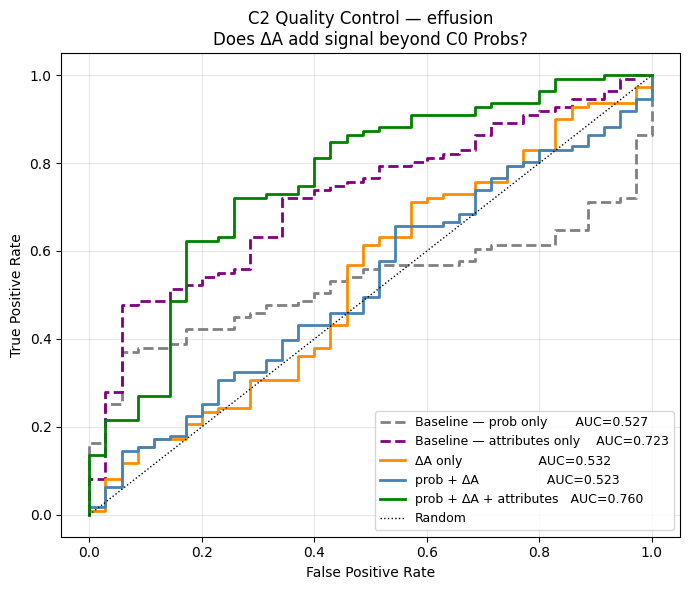

In [135]:
# Plot all three ROC curves together for comparison
plt.figure(figsize=(7, 6))
plt.plot(fpr_base, tpr_base, color='gray',       lw=2, ls='--', label=f'Baseline — prob only       AUC={auc_base:.3f}')
plt.plot(fpr_attr, tpr_attr, color='purple',      lw=2, ls='--', label=f'Baseline — attributes only    AUC={auc_attr:.3f}')

plt.plot(fpr_diff, tpr_diff, color='darkorange',  lw=2,          label=f'ΔA only                   AUC={auc_diff:.3f}')
plt.plot(fpr_comb, tpr_comb, color='steelblue',   lw=2,          label=f'prob + ΔA                 AUC={auc_comb:.3f}')
plt.plot(fpr_ext, tpr_ext, color='green',        lw=2,          label=f'prob + ΔA + attributes   AUC={auc_ext:.3f}')
plt.plot([0, 1], [0, 1], 'k:', lw=1, label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'C2 Quality Control — {DISEASE}\nDoes ΔA add signal beyond C0 Probs?')
plt.legend(loc='lower right', fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [136]:
print(f"Disease        : {DISEASE}")
print(f"Train size     : {len(train_filtered):,}  (correct: {y_train.sum():,} | incorrect: {(1-y_train).sum():,})")
print(f"Valid size     : {len(valid_filtered):,}  (correct: {y_valid.sum():,} | incorrect: {(1-y_valid).sum():,})")
print(f"Features       : {len(relevant_columns)}  {relevant_columns}")
print(f"ΔA shape       : train={train_diff.shape}  valid={valid_diff.shape}")

Disease        : effusion
Train size     : 35,637  (correct: 26,183 | incorrect: 9,454)
Valid size     : 146  (correct: 111 | incorrect: 35)
Features       : 84  ['margin', 'age_pred', 'sex_male', 'sex_female', 'race_white', 'race_black', 'race_asian', 'Left Clavicle_area_pixels', 'Left Clavicle_bbox_width', 'Left Clavicle_bbox_height', 'Left Clavicle_bbox_ratio', 'Left Clavicle_perimeter', 'Left Scapula_area_pixels', 'Left Scapula_bbox_width', 'Left Scapula_bbox_height', 'Left Scapula_bbox_ratio', 'Left Scapula_perimeter', 'Right Scapula_area_pixels', 'Right Scapula_bbox_width', 'Right Scapula_bbox_height', 'Right Scapula_bbox_ratio', 'Right Scapula_perimeter', 'Left Lung_area_pixels', 'Left Lung_bbox_width', 'Left Lung_bbox_height', 'Left Lung_bbox_ratio', 'Left Lung_perimeter', 'Right Lung_area_pixels', 'Right Lung_bbox_width', 'Right Lung_bbox_height', 'Right Lung_bbox_ratio', 'Right Lung_perimeter', 'Left Hilus Pulmonis_area_pixels', 'Left Hilus Pulmonis_bbox_width', 'Left Hilus P

In [138]:
# %%
# Quick test — Random Forest to check if non-linearity helps
def train_and_eval_rf(X_train, X_valid, y_train, y_valid, label):
    model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
    model.fit(X_train, y_train)
    y_prob = model.predict_proba(X_valid)[:, 1]
    auc_score = roc_auc_score(y_valid, y_prob)
    print(f"RF — {label:<45} AUC = {auc_score:.4f}")
    return auc_score

train_and_eval_rf(train_filtered[['prob']].values, valid_filtered[['prob']].values, y_train, y_valid, "Baseline — prob only")
train_and_eval_rf(train_filtered[relevant_columns].values, valid_filtered[relevant_columns].values, y_train, y_valid, "Baseline — original attributes only")
train_and_eval_rf(train_diff, valid_diff, y_train, y_valid, "ΔA only")
train_and_eval_rf(np.hstack([train_filtered[['prob']].values, train_diff]), np.hstack([valid_filtered[['prob']].values, valid_diff]), y_train, y_valid, "Combined — prob + ΔA")
train_and_eval_rf(np.hstack([train_filtered[['prob']].values, train_diff, train_filtered[relevant_columns].values]),
                  np.hstack([valid_filtered[['prob']].values, valid_diff, valid_filtered[relevant_columns].values]),
                  y_train, y_valid, "Extended — prob + ΔA + original attributes")

RF — Baseline — prob only                          AUC = 0.6560
RF — Baseline — original attributes only           AUC = 0.6807
RF — ΔA only                                       AUC = 0.6048
RF — Combined — prob + ΔA                          AUC = 0.6992
RF — Extended — prob + ΔA + original attributes    AUC = 0.7042


0.7042471042471043

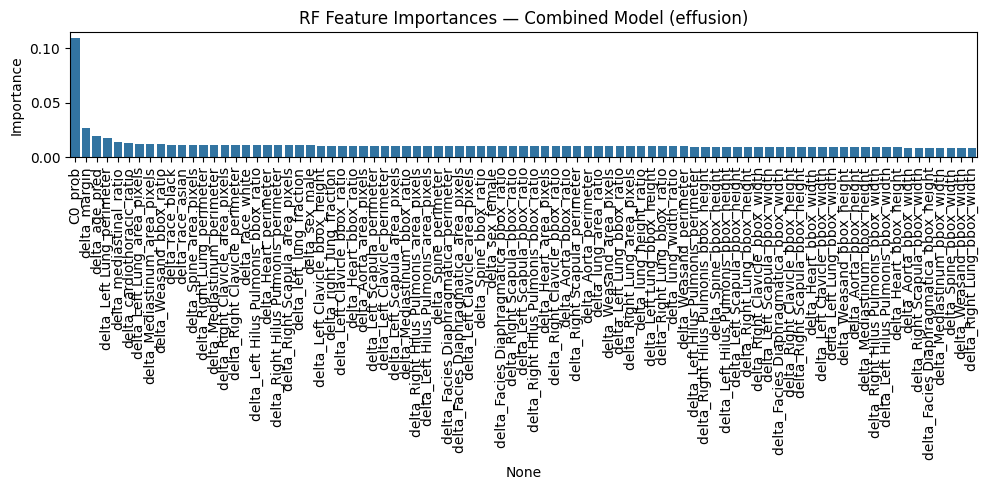

C0_prob                                    0.108969
delta_margin                               0.026726
delta_age_pred                             0.019459
delta_Left Lung_perimeter                  0.017717
delta_mediastinal_ratio                    0.014345
                                             ...   
delta_Facies Diaphragmatica_bbox_height    0.008857
delta_Mediastinum_bbox_width               0.008735
delta_Spine_bbox_width                     0.008693
delta_Weasand_bbox_width                   0.008525
delta_Right Lung_bbox_width                0.008504
Length: 85, dtype: float64


In [140]:
# %%
# The combined RF is the strongest model so far.
# Let's look at which attributes are driving it.

X_train_comb = np.hstack([train_filtered[['prob']].values, train_diff])
X_valid_comb = np.hstack([valid_filtered[['prob']].values,  valid_diff])

rf_comb = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_comb.fit(X_train_comb, y_train)

feature_names = ['C0_prob'] + diff_col_names
importances   = pd.Series(rf_comb.feature_importances_, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=importances.index, y=importances.values)
plt.xticks(rotation=90)
plt.title(f'RF Feature Importances — Combined Model ({DISEASE})')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

print(importances)


In [ ]:
# %%

def train_and_eval_mlp(X_train, X_valid, y_train, y_valid, label):
    from sklearn.preprocessing import StandardScaler
    scaler  = StandardScaler()
    X_tr_sc = scaler.fit_transform(X_train)
    X_va_sc = scaler.transform(X_valid)
    model   = MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=500, random_state=42)
    model.fit(X_tr_sc, y_train)
    y_prob  = model.predict_proba(X_va_sc)[:, 1]
    auc_score = roc_auc_score(y_valid, y_prob)
    print(f"MLP — {label:<45} AUC = {auc_score:.4f}")
    return auc_score, fpr, tpr

train_and_eval_mlp(train_filtered[['prob']].values, valid_filtered[['prob']].values, y_train, y_valid, "Baseline — prob only")
train_and_eval_mlp(train_filtered[relevant_columns].values, valid_filtered[relevant_columns].values, y_train, y_valid, "Baseline — original attributes only")   
train_and_eval_mlp(train_diff, valid_diff, y_train, y_valid, "ΔA only")
train_and_eval_mlp(np.hstack([train_filtered[['prob']].values, train_diff]), np.hstack([valid_filtered[['prob']].values, valid_diff]), y_train, y_valid, "Combined — prob + ΔA")
train_and_eval_mlp(np.hstack([train_filtered[['prob']].values, train_diff, train_filtered[relevant_columns].values]),
                   np.hstack([valid_filtered[['prob']].values, valid_diff, valid_filtered[relevant_columns].values]),
                   y_train, y_valid, "Extended — prob + ΔA + original attributes")

MLP — Baseline — prob only                          AUC = 0.7169


MLP — Baseline — original attributes only           AUC = 0.6746
MLP — ΔA only                                       AUC = 0.6126
MLP — Combined — prob + ΔA                          AUC = 0.7274
MLP — Extended — prob + ΔA + original attributes    AUC = 0.8088


0.8087516087516087